In [3]:
# import os
# import pandas as pd
# import json

# def discogs_to_dict(discogs_path: str) -> dict:
#     dataset = {}
#     with open(discogs_path, "r") as f:
#         for line in f:
#             clique = json.loads(line)
#             clique_id = clique.pop("clique_id")
#             dataset[clique_id] = clique
#     return dataset

# print("Load discogs...")
# discogs = discogs_to_dict("data/discogs/Discogs-VI-YT-20240701.jsonl")


In [ ]:
import os
import pandas as pd

if not os.path.isfile("data/matched/filtered_max.csv"):
    print("Load matched...")
    df = pd.read_csv("data/matched/full.csv", sep="\t")
    df = df
    df.youtube_id = df.youtube_id.astype("category")
    df.clique_id = df.clique_id.astype("category")
    df.youtube_attr = df.youtube_attr.astype("category")
    df.discogs_attr = df.discogs_attr.astype("category")
    print("Group...")
    grouped = (
    df.groupby(["youtube_id", "clique_id", "youtube_attr", "discogs_attr"], sort=False, observed=True)["Score"]
      .max()
    ).to_frame()
    grouped.to_csv("data/matched/filtered_max.csv", sep="\t")
else:
    print("Load matched grouped...")
    grouped = pd.read_csv("data/matched/filtered_max.csv", sep="\t")
    df = pd.read_csv("data/matched/full.csv", sep="\t")


Load matched...
Group...


# Match Analysis
## Distributions per attribute combination

In [5]:
df_temp = grouped.copy()
df_temp = df_temp.reset_index()
df_temp["pair"] = df_temp.youtube_attr.astype("str") + " to " + df_temp.discogs_attr.astype("str")
df_temp["pair"] = df_temp["pair"].astype("category")


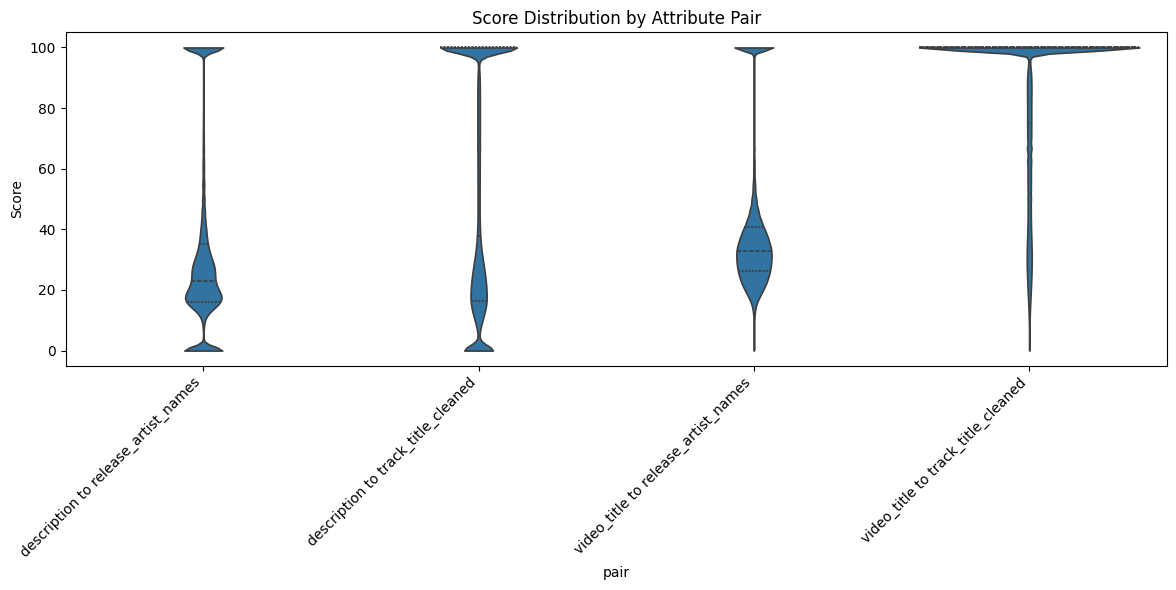

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.violinplot(x="pair", y="Score", data=df_temp, inner="quartile", cut=0)
plt.xticks(rotation=45, ha='right')
plt.title("Score Distribution by Attribute Pair")
plt.tight_layout()
plt.show()


## Sub-Groups
Given a relatively high minimum similarity, we split into the following groups:
- artist + title match
- only title match
- only artist match
- nothing matches 

In [7]:
threshold = 80
df_temp = grouped.copy()
df_temp["Matched"] = df_temp["Score"] > threshold
df_temp = df_temp.reset_index()

pivot = df_temp.pivot_table(
    index=["youtube_id", "clique_id"],
    columns="discogs_attr",
    values="Matched",
    aggfunc="any",  # True if *any* row for that attr is matched
    fill_value=False,
    observed=True
)

def classify_match(row):
    artist = row.get("release_artist_names", False)
    title = row.get("track_title_cleaned", False)
    
    if artist and title:
        return "both"
    elif artist:
        return "only_release_artist_names"
    elif title:
        return "only_track_title_cleaned"
    else:
        return "none"

pivot["match_type"] = pivot.apply(classify_match, axis=1)
pivot.to_csv("data/matched/filtered_types.csv", sep="\t")

counts = pivot["match_type"].value_counts().reset_index()
counts['count'] = counts['count'].apply(lambda x: f"{x:,}")
print(counts)


                  match_type      count
0   only_track_title_cleaned  4,045,147
1                       none  1,791,147
2                       both  1,445,078
3  only_release_artist_names     94,838


## Get Sample for manuall annotation

In [13]:
sample = pivot.groupby("match_type").sample(100)

sample = pd.merge(
    sample.reset_index(),
    df,
    on=["youtube_id", "clique_id"],
    how="left"
)
sample = sample.drop(columns=["youtube_attr", "Score"])
sample = sample.drop_duplicates()

discogs_attr_values = sample['discogs_attr'].unique().tolist()
group_cols = [col for col in sample.columns if col not in ['discogs_attr', 'discogs_text'] + discogs_attr_values]

# Pivot and aggregate
sample = sample.pivot_table(
    index=group_cols,
    columns='discogs_attr',
    values='discogs_text',
    aggfunc=lambda x: list(x),
    observed=True,
).reset_index()

sample.columns.name = None
sample.track_title_cleaned = sample.track_title_cleaned.apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None)
sample = sample.sort_values(by=["match_type"])
sample.to_csv("data/matched/filtered_sample.csv", sep="\t", index=False)
sample


,youtube_id,clique_id,match_type,release_artist_names,track_title_cleaned
298,hqWa0ShLRhE,C-0146800,both,"[Maroon 5, Rihanna]",if i never see your face again
244,_UrjQSVbIkk,C-0068099,both,"[Antonio Forcione, Sweetwater, Al Jarreau, The...",compared to what
110,GXhETLg4jqc,C-0039147,both,"[Guns N' Roses, Maziora The Band, N-Trance, Ak...",paradise city
249,aTHC7nQ6Q9s,C-0184131,both,"[Arthur Lyman, Maynard Ferguson, Herbie Mann]",carabunta
251,agkiJUDwI-Y,C-0227517,both,"[The Forester Sisters, Doug Stone, Johnny Bush...",these lips dont know how to say goodbye
...,...,...,...,...,...
215,WpwauhhBD_0,C-0195451,only_track_title_cleaned,"[Orquesta Típica Española, Juan Ramón Fuentes,...",yo quiero ser matador
119,HtsN_fMOfsk,C-0229676,only_track_title_cleaned,"[The Bluegrass Parlor Band, Carl Story & His R...",light at the river
217,WtA42OsmfrQ,C-0079118,only_track_title_cleaned,"[Luis Oliveira And His Bandodalua Boys, DJ BoBo]",chihuahua
102,FLzGtrwyCBA,C-0105231,only_track_title_cleaned,"[Patsy Cline, Cowboy Copas, Hawkshaw Hawkins, ...",beyond the sunset
